# Clustering

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, silhouette_samples

## K-means and Silhouette score

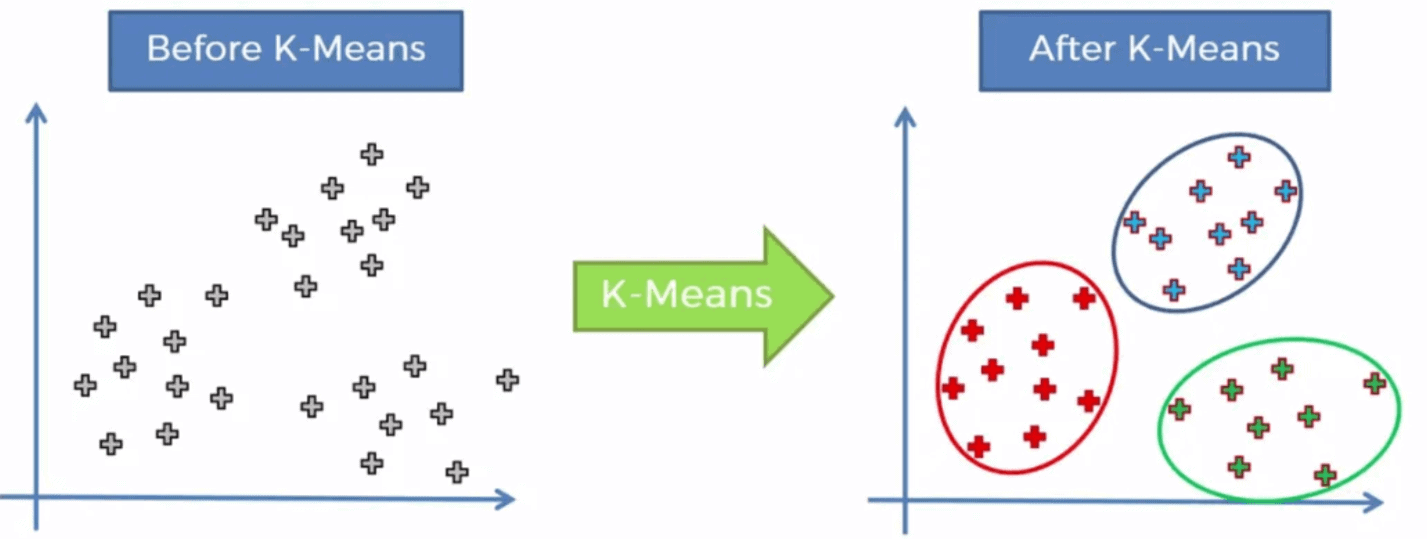

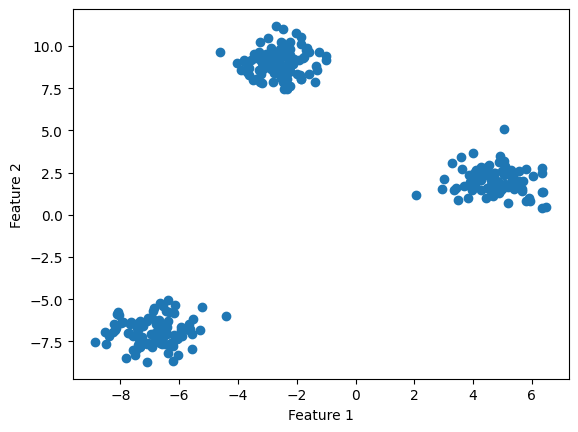

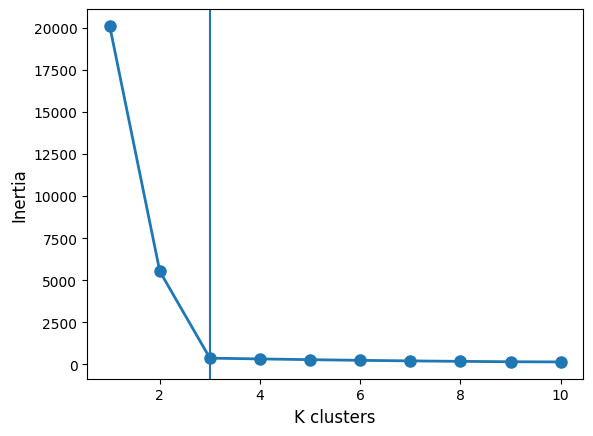

In [27]:
X, y = make_blobs(n_samples=300, centers=3, 
                       cluster_std=0.8, random_state=42)

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

plt.plot(K_range, inertias, 'o-', linewidth=2, markersize=8)
plt.xlabel('K clusters', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.axvline(3)
plt.show()

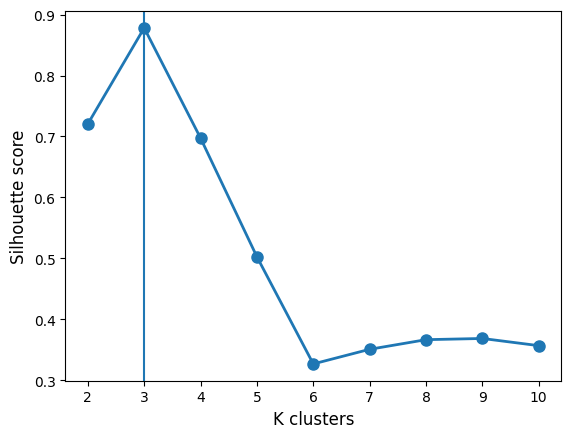

In [28]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.plot(K_range, silhouette_scores, 'o-', linewidth=2, markersize=8)
plt.xlabel('K clusters', fontsize=12)
plt.ylabel('Silhouette score', fontsize=12)
plt.axvline(3)
plt.show()

## DBSCAN

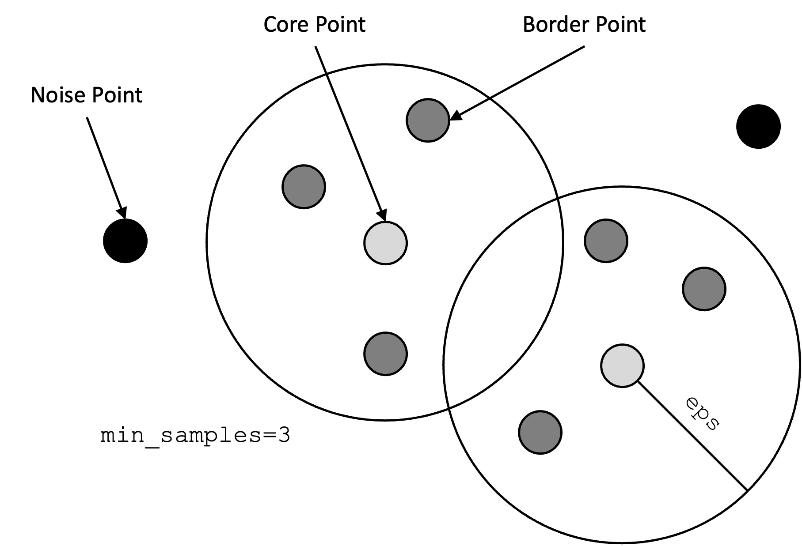

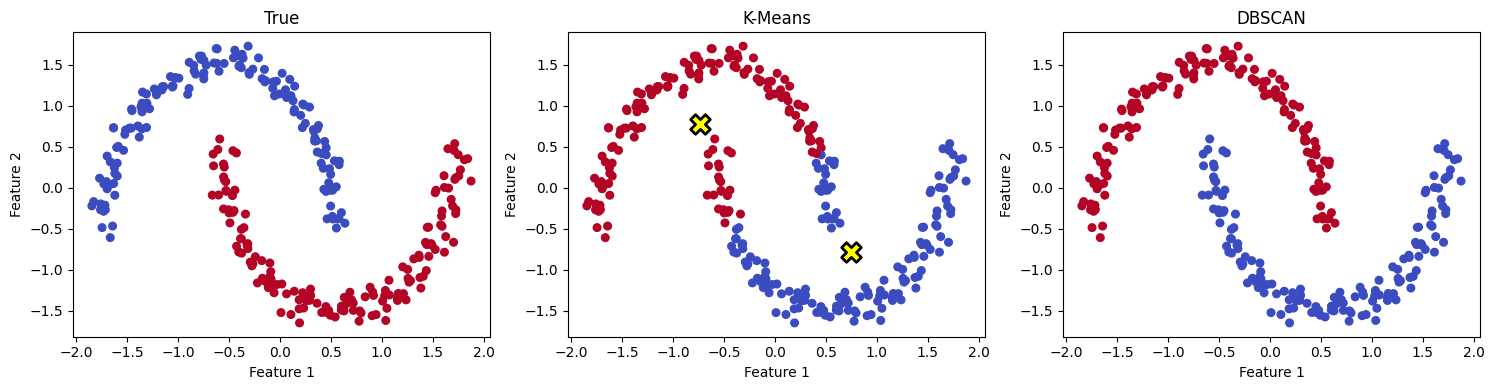


K-Means - Silhouette score: 0.495
DBSCAN - Silhouette score: 0.386


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', s=30)
axes[0].set_title('True', fontsize=12)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='coolwarm', s=30)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='yellow', marker='X', s=200, edgecolors='black', linewidths=2)
axes[1].set_title(f'K-Means', fontsize=12)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='coolwarm', s=30)
noise_mask = dbscan_labels == -1
axes[2].scatter(X_scaled[noise_mask, 0], X_scaled[noise_mask, 1], 
                c='black', marker='.', s=30, alpha=0.5, label='Noise')
axes[2].set_title(f'DBSCAN', fontsize=12)
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

dbscan_labels_no_noise = dbscan_labels[dbscan_labels != -1]
X_no_noise = X_scaled[dbscan_labels != -1]

print(f"\nK-Means - Silhouette score: {silhouette_score(X_scaled, kmeans_labels):.3f}")
print(f"DBSCAN - Silhouette score: {silhouette_score(X_scaled, dbscan_labels):.3f}")

# Dimension reduction

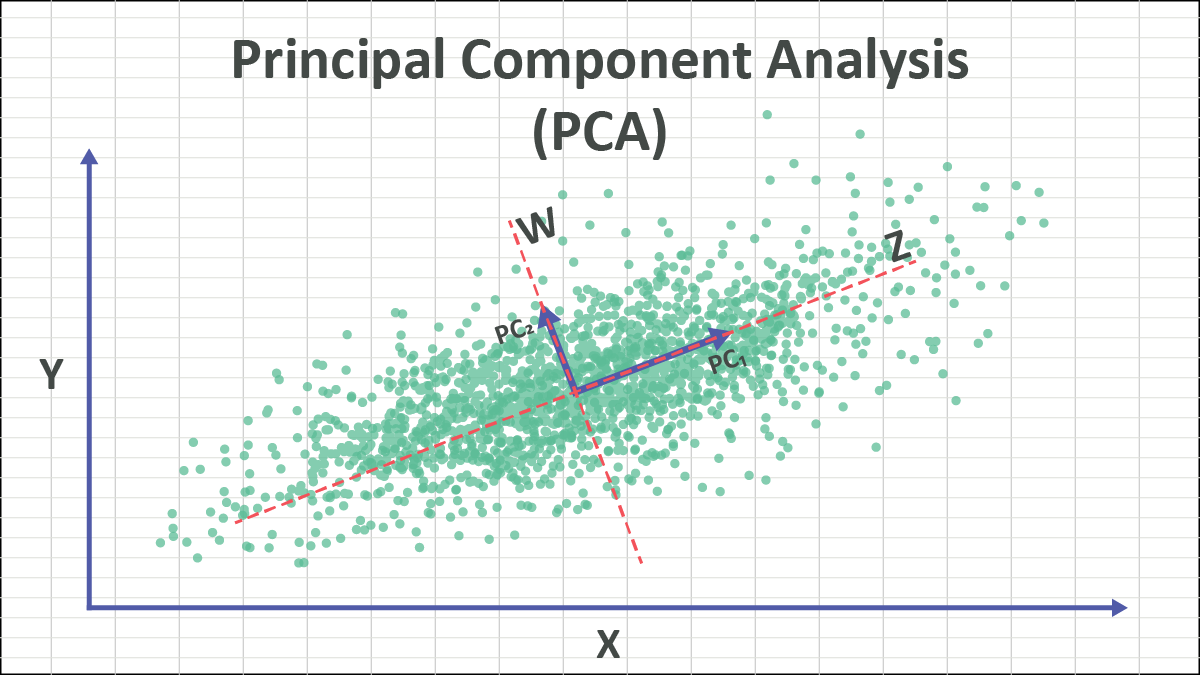

Shape: (1000, 3)

Information saved with PCA: 95.07%


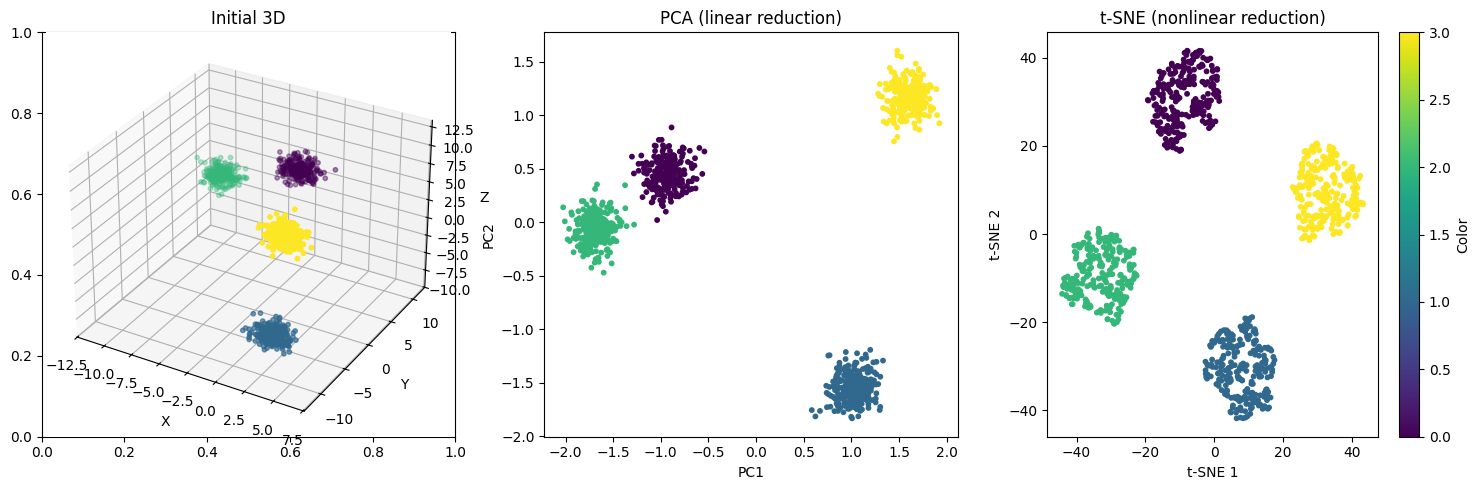

In [38]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X, y = make_blobs(n_samples=1000, n_features=3, centers=4, 
                   cluster_std=0.8, random_state=42)

print(f"Shape: {X.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"\nInformation saved with PCA: {pca.explained_variance_ratio_.sum():.2%}")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = fig.add_subplot(1, 3, 1, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', s=10)
ax.set_title('Initial 3D', fontsize=12)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=10)
axes[1].set_title('PCA (linear reduction)', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

scatter = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', s=10)
axes[2].set_title('t-SNE (nonlinear reduction)', fontsize=12)
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')

plt.colorbar(scatter, ax=axes[2], label='Color')
plt.tight_layout()
plt.show()

Shape: (1797, 64)

Information saved with PCA: 21.59%


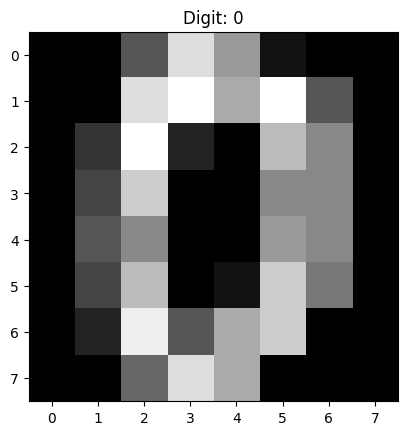

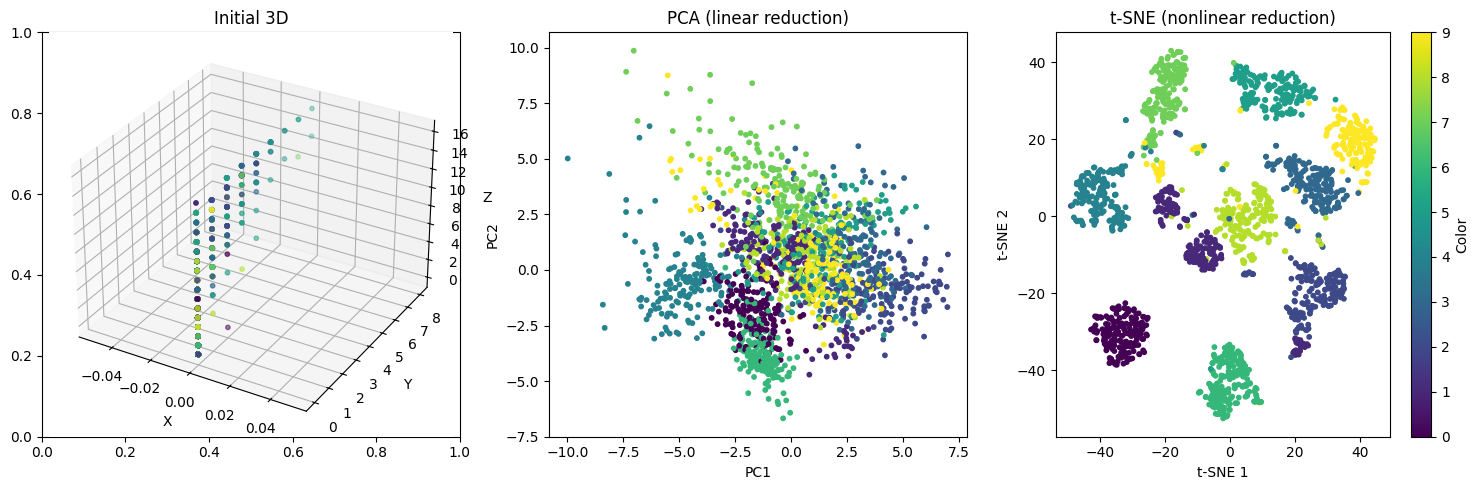

In [49]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target

print(f"Shape: {X.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"\nInformation saved with PCA: {pca.explained_variance_ratio_.sum():.2%}")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

first_digit = X[0].reshape(8, 8)

plt.imshow(first_digit, cmap='gray')
plt.title(f"Digit: {y[0]}")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = fig.add_subplot(1, 3, 1, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', s=10)
ax.set_title('Initial 3D', fontsize=12)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=10)
axes[1].set_title('PCA (linear reduction)', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

scatter = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', s=10)
axes[2].set_title('t-SNE (nonlinear reduction)', fontsize=12)
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')

plt.colorbar(scatter, ax=axes[2], label='Color')
plt.tight_layout()
plt.show()

# Personal task
* Use dimension reduction methods to improve the quality of your models in one of the tasks.
* Explain the method choice and n_components.
* Visualize data after the reduction procedure.